# Testing Python Spin Integrators

In [1]:
import simulation
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda
import cupy as cp
import cupyx

In [2]:
params = simulation.defineSimulation(tf=1)

In [3]:
@simulation.numba.jit
def EField(t, x):
	out = x[:]
	out[0] = 75.0e-5 #75.0e-5
	out[1] = 0.0
	out[2] = 0.0 #75.0e-5
	return out

@simulation.numba.jit
def BField(t, x):
	out = x[:]
	out[0] = 30.0e-7 #0.0 #
	out[1] = 0.0
	out[2] = 0.0 #38.7511230e-6*np.cos(6000*t) + 30.0e-7
	return out

In [4]:
outputTimes = np.linspace(0, 1.0, 1000)
particle = simulation.createParticle(params, seed=0, spin=(0.0, 0.0, 1.0))
spinSettings = simulation.spinIntegratorOptions(integrator=11, h=0.000001)

In [5]:
initial = np.copy(particle)
particle = simulation.calc_next_collision_time(particle, params)
particle = simulation.move(particle, params)
particle = simulation.new_velocities(particle, params)

In [6]:
particle['last_spin_step_size'] = spinSettings['h']
particle = simulation.spin.perturbativeIntegratorRK45(particle, spinSettings, params, BField, EField)
print(particle['n_spin_steps'], particle['last_spin_step_size'])

26 1.0834705943388392e-05


In [32]:
outputTimes = np.linspace(0, 2.0, 10000)
results = []

names = ['DOP853']
names.append('DOP853 Rot')
names.append('DOP853 Quat')
names.append('RK45')
names.append('RK45 Rot')
names.append('RK45 Quat')
names.append('RK75109')
names.append('RK75109 Rot')
names.append('RK75109 Quat')
names.append('Imp Euler')
names.append('Crank-Nicolson')
names.append('perturbative')

ran = []

for integrator in [0, 3, 4, 5]:
	print(integrator)
	start = time.time()
	params = simulation.defineSimulation(tf=2)
	particle = simulation.createParticle(params, seed=0, spin=(0.0, 0.0, 1.0))
	spinSettings = simulation.spinIntegratorOptions(integrator=integrator, h=0.0000001, rtol=1.0e-14, atol=1.0e-14)
	tempRes = [particle]
	for i in range(1, len(outputTimes)):
		particle['finished'] = 0
		params['t0'] = outputTimes[i-1]
		params['tf'] = outputTimes[i]
		particle = simulation.run(particle, params, spinSettings, BField, EField)
		tempRes.append(np.copy(particle))
	print('\t', time.time()-start)
	results.append(tempRes)
	ran.append(names[integrator])
results = np.array(results)

0
	 3.951505422592163
3
	 5.073441028594971
4
	 4.940039157867432
5
	 4.40893292427063


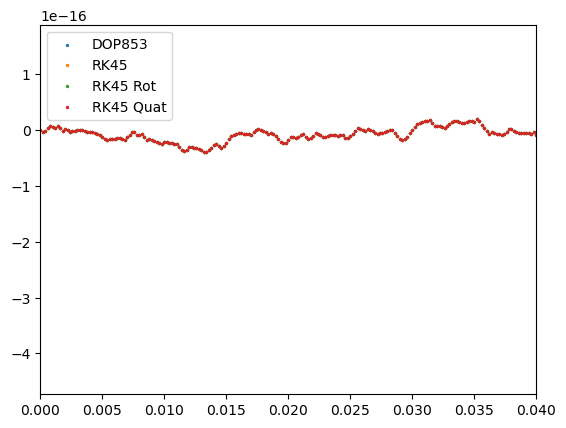

In [33]:
coordinate = 0
for i in range(len(results)):
	res = results[i]
	plt.scatter(res['t'], res['s'][:,coordinate], label=ran[i], s=2)
plt.xlim(0, 0.04)
plt.legend()
#plt.yscale('log')
plt.show()

-0.01142934480769253


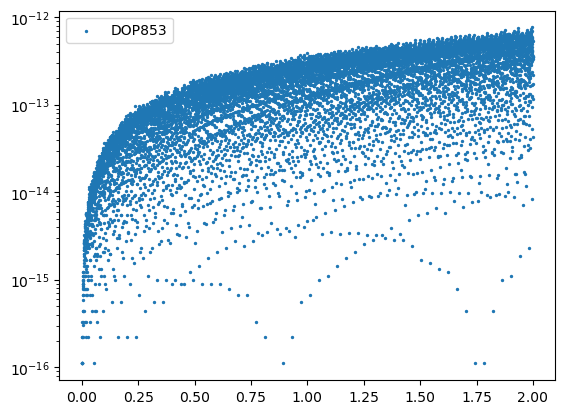

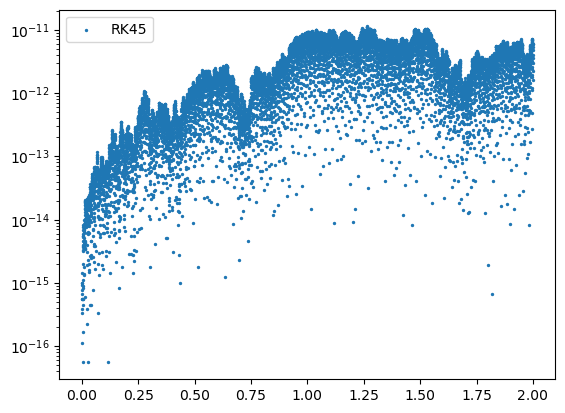

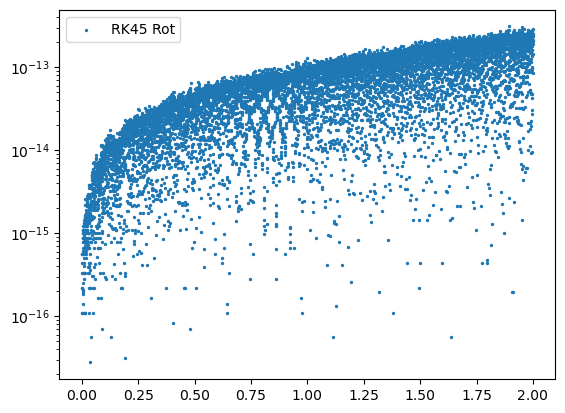

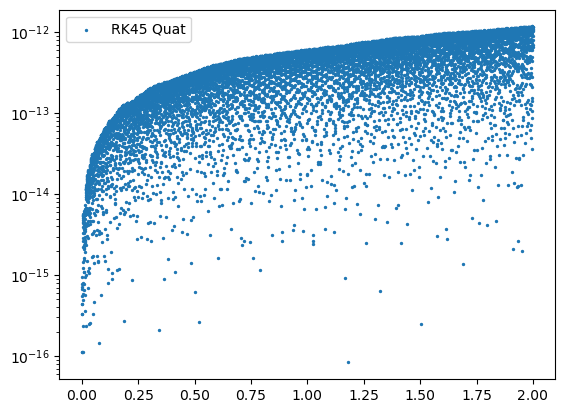

In [35]:
w = np.sqrt(np.sum(np.square(BField(0, np.zeros(3)))))*-1.83247171E8
period = np.pi * 2.0 / w
print(period)
truth = np.cos(outputTimes/period*np.pi*2.0)
coordinate = 2

for i in range(len(results)):
	res = results[i]
	plt.scatter(res['t'], abs(res['s'][:,coordinate]-truth), label=ran[i], s=2)
	#plt.xlim(0, 1.0)
	plt.legend()
	plt.yscale('log')
	#plt.scatter(results[0]['t'], results[0]['coll_type'])
	plt.show()

In [13]:
particle = simulation.createParticle(params)
output = simulation.run(particle, params, spinSettings, BField, EField)

(0., [ 0.00708841,  0.02477741, -0.158792  ], [1.59271556, 2.80241474, 3.82226749], [1., 0., 0.], 1.1e-26, [18099470064188344476,   209881849482811108,  4214679493675457371,  1572670624253100611], 0., 0., [ 0.00708841,  0.02477741, -0.158792  ], [1.59271556, 2.80241474, 3.82226749], -2.078e+08, 0.00019451, 0.0001067, 0, 0, 0, 0, 0, 0, 0)


In [14]:
simulation.step(particle, params, spinSettings, BField, EField)

(0.0001067, [ 0.00725835,  0.02507637, -0.15838417], [-3.93685778, -0.18935998,  3.07561928], [ 9.98280153e-01, -5.86236836e-02, -9.85284186e-19], 1.1e-26, [17927633202968970623, 12350831045657136816,  7029980979775108876,  9626008024046592686], 0.0001067, 0., [ 0.00708841,  0.02477741, -0.158792  ], [1.59271556, 2.80136909, 3.82226749], -2.078e+08, 0.00019451, 0.00025592, 2, 0, 0, 0, 1, 1, 2)

In [15]:
particle = simulation.createParticle(params)
simulation.run(particle, params, spinSettings, BField, EField)

(100., [-0.03186413, -0.04514666,  0.03064882], [ 1.37449967,  4.84853063, -0.98641427], [-8.37258843e-01, -5.46806758e-01, -4.33574261e-16], 1.1e-26, [14337434724619314969, 15470440208904151190,  9378450917558791726, 15303395685055223321], 0.00012059, 99.99987941, [-0.03202989, -0.04573143,  0.03076777], [ 1.37449967,  4.84853063, -0.98641427], -2.078e+08, 0.00019451, 100.0000222, 0, 0, 1, 6643, 513130, 519774, 877904)

In [16]:
def dumbTest():
	particle = simulation.createParticle(params)
	output = simulation.run(particle, params, spinSettings, BField, EField)
	return output

In [17]:
%timeit dumbTest()

9.07 s ± 120 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
particle

(1., [-0.03387645,  0.04315252, -0.13708652], [3.04524708, 3.40486385, 1.94247784], [-9.99308109e-01, -3.71927981e-02,  2.82872528e-17], 1.1e-26, [ 4836140179057685063, 12096664131365930449, 15388404387858936191,  1983322891719267919], 2.24422415e-05, 0.99997756, [-0.0339448 ,  0.04307611, -0.13713012], [3.04524708, 3.40486385, 1.94247784], -2.078e+08, 0.00019451, 1.00040531, 0, 0, 1, 55, 5186, 5242, 8844)

In [ ]:
output==particle

In [ ]:
%timeit simulation.run(particle, params, spinSettings, EField, BField)

In [ ]:
states = [particle]
while particle['finished'] == 0:
	particle = simulation.calc_next_collision_time(particle, params)
	particle = simulation.move(particle, params)
	particle = simulation.new_velocities(particle, params)
	particle = simulation.spin.integrateSpin(particle, params, spinSettings, EField, BField)
	states.append(particle)
states = np.array(states)

In [ ]:
plt.scatter(states['t'], states['s'][:,0])
plt.xlim(0, 0.1)
plt.show()

In [ ]:
initSpin = np.array([1.0, 0.0, 0.0])
p = np.zeros(3)
v = np.zeros(3)

In [ ]:
outTimes = np.linspace(0, 0.1, 1000)
lastT = outTimes[0]
outDOP853 = [initSpin[:]]
outDOP853Rotation = [initSpin[:]]
outDOP853Quat = [initSpin[:]]
outRK45 = [initSpin[:]]
outRK45Rotation = [initSpin[:]]
outRK45Quat = [initSpin[:]]
outRK75109 = [initSpin[:]]
outRK75109Rotation = [initSpin[:]]
outImplicitEuler = [initSpin[:]]
outCrankNicolson = [initSpin[:]]
for T in outTimes[1:]:
	outDOP853.append(SpinInt.DOP853(lastT, T, np.copy(outDOP853[-1]), p, p, v, v, options, BField, EField)[0])
	outDOP853Rotation.append(SpinInt.DOP853Rotation(lastT, T, np.copy(outDOP853Rotation[-1]), p, p, v, v, options, BField, EField)[0])
	outDOP853Quat.append(SpinInt.DOP853Quaternion(lastT, T, np.copy(outDOP853Quat[-1]), p, p, v, v, options, BField, EField)[0])
	outRK45.append(SpinInt.RK45(lastT, T, np.copy(outRK45[-1]), p, p, v, v, options, BField, EField)[0])
	outRK45Rotation.append(SpinInt.RK45Rotation(lastT, T, np.copy(outRK45Rotation[-1]), p, p, v, v, options, BField, EField)[0])
	outRK45Quat.append(SpinInt.RK45Quaternion(lastT, T, np.copy(outRK45Quat[-1]), p, p, v, v, options, BField, EField)[0])
	outRK75109.append(SpinInt.RK75109(lastT, T, np.copy(outRK75109[-1]), p, p, v, v, options, BField, EField)[0])
	outRK75109Rotation.append(SpinInt.RK75109Rotation(lastT, T, np.copy(outRK75109Rotation[-1]), p, p, v, v, options, BField, EField)[0])
	outImplicitEuler.append(SpinInt.ImplicitEuler(lastT, T, np.copy(outImplicitEuler[-1]), p, p, v, v, options, BField, EField)[0])
	outCrankNicolson.append(SpinInt.CrankNicolson(lastT, T, np.copy(outCrankNicolson[-1]), p, p, v, v, options, BField, EField)[0])
	lastT = T
outDOP853 = np.array(outDOP853)
outDOP853Rotation = np.array(outDOP853Rotation)
outDOP853Quat = np.array(outDOP853Quat)
outRK45 = np.array(outRK45)
outRK45Rotation = np.array(outRK45Rotation)
outRK45Quat = np.array(outRK45Quat)
outRK75109 = np.array(outRK75109)
outRK75109Rotation = np.array(outRK75109Rotation)
outImplicitEuler = np.array(outImplicitEuler)
outCrankNicolson = np.array(outCrankNicolson)

In [ ]:
coord = 0
region = None
plt.plot(outTimes, outDOP853[:,coord], label='DOP853')
#plt.plot(outTimes, outDOP853Rotation[:,coord], label='DOP853 Rotation')
#plt.plot(outTimes, outDOP853Quat[:,coord], label='DOP853 Quaternion')
plt.plot(outTimes, outRK45[:,coord], label='RK45')
plt.plot(outTimes, outRK45Rotation[:,coord], label='RK45 Rotation')
plt.plot(outTimes, outRK45Quat[:,coord], label='RK45 Quaternion')
plt.plot(outTimes, outRK75109[:,coord], label='RK75109')
plt.plot(outTimes, outRK75109Rotation[:,coord], label='RK75109 Rotation')
#plt.plot(outTimes, outImplicitEuler[:,coord], label='Implicit Euler')
plt.plot(outTimes, outCrankNicolson[:,coord], label='Crank Nicolson')
plt.xlim(region)
plt.legend(loc='upper right')
plt.show()

In [ ]:
%timeit SpinInt.DOP853(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
%timeit SpinInt.DOP853Rotation(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
%timeit SpinInt.DOP853Quaternion(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
print()
%timeit SpinInt.RK45(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
%timeit SpinInt.RK45Rotation(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
%timeit SpinInt.RK45Quaternion(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
print()
%timeit SpinInt.RK75109(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
%timeit SpinInt.RK75109Rotation(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
print()
%timeit SpinInt.ImplicitEuler(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
%timeit SpinInt.CrankNicolson(0, 1.0, np.copy(initSpin), p, p, v, v, options, BField, EField)
print()

In [ ]:
hs = np.logspace(-3, -7, 5)
options['rtol'] = 1.0E-13
options['atol'] = 1.0E-13
options['h'] = 1.0E-6

stepsDOP853 = SpinInt.DOP853(outTimes[0], outTimes[-1], np.copy(outDOP853[-1]), p, p, v, v, options, BField, EField)[1]
stepsRK45 = SpinInt.RK45(outTimes[0], outTimes[-1], np.copy(outRK45[-1]), p, p, v, v, options, BField, EField)[1]
stepsRK75109 = SpinInt.RK75109(outTimes[0], outTimes[-1], np.copy(outRK75109[-1]), p, p, v, v, options, BField, EField)[1]

In [ ]:
outDOP853 = [initSpin[:]]
outRK45 = [initSpin[:]]
outRK75109 = [initSpin[:]]

outTimes = np.linspace(0, 1.0, 10000)
lastT = outTimes[0]
for T in outTimes[1:]:
	outDOP853.append(SpinInt.DOP853(lastT, T, np.copy(outDOP853[-1]), p, p, v, v, options, BField, EField)[0])
	outRK45.append(SpinInt.RK45(lastT, T, np.copy(outRK45[-1]), p, p, v, v, options, BField, EField)[0])
	outRK75109.append(SpinInt.RK75109(lastT, T, np.copy(outRK75109[-1]), p, p, v, v, options, BField, EField)[0])
	lastT = T
outDOP853 = np.array(outDOP853)
outRK45 = np.array(outRK45)
outRK75109 = np.array(outRK75109)
for h in hs:
	print(h)
	options['h'] = h
	outTimes = np.linspace(0, 1.0, 10000)
	lastT = outTimes[0]
	outImplicitEuler = [initSpin[:]]
	outCrankNicolson = [initSpin[:]]
	stepsEuler = SpinInt.ImplicitEuler(outTimes[0], outTimes[-1], np.copy(outImplicitEuler[-1]), p, p, v, v, options, BField, EField)[1]
	stepsCrank = SpinInt.CrankNicolson(outTimes[0], outTimes[-1], np.copy(outCrankNicolson[-1]), p, p, v, v, options, BField, EField)[1]
	for T in outTimes[1:]:
		outImplicitEuler.append(SpinInt.ImplicitEuler(lastT, T, np.copy(outImplicitEuler[-1]), p, p, v, v, options, BField, EField)[0])
		outCrankNicolson.append(SpinInt.CrankNicolson(lastT, T, np.copy(outCrankNicolson[-1]), p, p, v, v, options, BField, EField)[0])
		lastT = T
	outImplicitEuler = np.array(outImplicitEuler)
	outCrankNicolson = np.array(outCrankNicolson)
	coord = 0
	region = 0.99, 1.0
	#plt.plot(outTimes, outDOP853[:,coord], label='DOP853 '+str(stepsDOP853))
	plt.plot(outTimes, abs(outRK45[:,coord] - outDOP853[:,coord]), label='RK45 '+str(stepsRK45))
	plt.plot(outTimes, abs(outRK75109[:,coord] - outDOP853[:,coord]), label='RK75109 '+str(stepsRK75109))
	plt.plot(outTimes, abs(outImplicitEuler[:,coord] - outDOP853[:,coord]), label='Implicit Euler '+str(stepsEuler))
	plt.plot(outTimes, abs(outCrankNicolson[:,coord] - outDOP853[:,coord]), label='Crank Nicolson '+str(stepsCrank))
	plt.xlim(region)
	plt.legend(loc='lower center')
	plt.title(h)
	plt.yscale('log')
	plt.show()